# 05a — Baseline: Logistic Regression
**RouteRight AI — Stage 6 (Model Development)** | Owner: *(write team member name / ID here)*

This notebook runs **one** baseline model — **Logistic Regression** — in two variants (unweighted and class-weighted) and records its results.
Everything that must be identical across the four models (data, `TimeSeriesSplit` folds, threshold, metric definitions, seed, weighting logic) lives in **`baseline_common.py`**, so the models are compared on exactly the same footing. The four results are merged in `05e_Baseline_Comparison.ipynb`.

* **Validation:** 5-fold `TimeSeriesSplit` on `train.csv` only — each fold trains on earlier rows and validates on the next block.
* **Metrics:** PR-AUC and F1 are primary (test set is more imbalanced than train: 37% vs 47% positive); accuracy, precision, recall, ROC-AUC also reported.
* **Test set:** never loaded. Kept sealed until `07_Model_Evaluation.ipynb`.
* **Baseline = library defaults.** Tuning is Stage 7.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

import baseline_common as bc

MODEL_NAME = "Logistic Regression"
print("Project root:", bc.ROOT)

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor


## 2. Load training data and sanity checks
Only `train.csv` is loaded. `load_train()` asserts no missing values, all-numeric features, and **chronological row order** (the assumption `TimeSeriesSplit` depends on; `opened_month` is the only time signal in this file).

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## 3. Validation folds
Fold 1 trains on only ~3,500 rows (mostly Feb/March), so per-fold scores are shown, not only the mean.
**Caveat:** train contains 1,865 exact duplicate rows; a duplicate can sit on both sides of a fold boundary, making validation scores slightly optimistic (most visibly for trees). They are kept, not dropped, to preserve the documented class balance.

In [3]:
bc.fold_table(X, y)

,fold,n_train,n_val,train_pos_rate,val_pos_rate,val_months
0,1,3530,3530,0.5521,0.6110,[3]
1,2,7060,3530,0.5816,0.4530,"[3, 4]"
2,3,10590,3530,0.5387,0.4261,[4]
3,4,14120,3530,0.5106,0.3742,"[4, 5]"
4,5,17650,3530,0.4833,0.4110,[5]


## Why Logistic Regression, and how it is set up
* **Role:** the simple **linear baseline** the other three models are judged against (named as the baseline in the proposal, Section 6.5). If nonlinear models do not clearly beat it, their extra complexity is not justified.
* **Scaling:** linear models are scale-sensitive, so it runs inside a `Pipeline` with `StandardScaler`. The scaler is fit on each fold's *training* rows only (never on validation rows).
* **Settings:** L2 penalty, `C=1.0` (defaults); `max_iter=1000` only so the solver converges. `C` and penalty are left for Stage 7.
* **Weighted variant:** `class_weight="balanced"`.
* **Known concern:** `priority_encoded` correlates ~0.9 with `impact_encoded` / `urgency_encoded`, which can make individual coefficients unstable — checked in Section 6.

In [4]:
bc.MODEL_FACTORIES[MODEL_NAME]("balanced")     # the weighted variant; unweighted is identical with class_weight=None

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be

## 4. Cross-validated results

In [5]:
folds_df, oof_df = bc.run_cv(MODEL_NAME, X, y)
summary = bc.summarize(folds_df)
summary[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "fit_seconds"]]

cross-validated: Logistic Regression (unweighted)
cross-validated: Logistic Regression (weighted)


,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,fit_seconds
0,Logistic Regression,unweighted,0.7178,0.0813,0.6245,0.6252,0.6634,0.6845,0.7501,0.7313,0.37
1,Logistic Regression,weighted,0.7175,0.0816,0.6207,0.5966,0.6748,0.6897,0.7498,0.7292,0.37


Per-fold PR-AUC next to the **no-skill level** (a model with no skill scores the positive rate of that validation block, so compare each fold against its own line, not against other folds).

In [6]:
bc.per_fold_view(folds_df)

,n_train,no_skill_pr_auc,pr_auc_unweighted,pr_auc_weighted
fold,,,,
1,3530,0.611,0.862,0.862
2,7060,0.453,0.701,0.699
3,10590,0.426,0.666,0.666
4,14120,0.374,0.677,0.677
5,17650,0.411,0.684,0.684


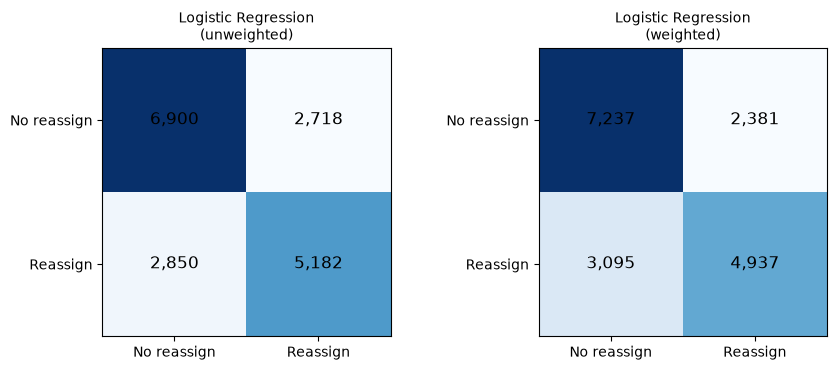

In [7]:
# Confusion matrices from pooled out-of-fold predictions (validation blocks of folds 1-5). Rows = actual, columns = predicted.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, variant in zip(axes, ["unweighted", "weighted"]):
    part = oof_df[oof_df.variant == variant]
    cm = confusion_matrix(part.y_true, part.y_pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No reassign", "Reassign"]); ax.set_yticklabels(["No reassign", "Reassign"])
    ax.set_title(f"{MODEL_NAME}\n({variant})", fontsize=10)
plt.tight_layout(); plt.savefig(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_confusion.png", dpi=130); plt.show()

## 5. Fit on the full training set and save
The model is refit on **all** of `train.csv` and saved to `models/baseline/`. Full-train accuracy is used in the comparison notebook to check against the training-accuracy ceiling. **No test data is used.**

In [8]:
full_df, fitted = bc.full_fit_and_save(MODEL_NAME, X, y)
bc.save_outputs(MODEL_NAME, folds_df, oof_df, full_df)
full_df

Saved results for Logistic Regression to C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\docs\deliverables_eval2


,model,variant,train_accuracy_full,train_f1_full
0,Logistic Regression,unweighted,0.7180,0.6887
1,Logistic Regression,weighted,0.7168,0.7015


## 6. Interpretation — Logistic Regression coefficients

In [9]:
lr = fitted["unweighted"]
coefs = pd.Series(lr.named_steps["clf"].coef_[0], index=X.columns).sort_values()
print("Features pushing toward NO reassignment (most negative coefficients):")
display(coefs.head(10).round(3).to_frame("coef"))
print("Features pushing toward REASSIGNMENT (most positive coefficients):")
display(coefs.tail(10)[::-1].round(3).to_frame("coef"))

print("Correlation among the three ordinal features (train):")
display(X[["impact_encoded", "urgency_encoded", "priority_encoded"]].corr().round(3))
print("Their Logistic Regression coefficients (standardised features):")
display(coefs[["impact_encoded", "urgency_encoded", "priority_encoded"]].round(3).to_frame("coef"))

Features pushing toward NO reassignment (most negative coefficients):


,coef
assignment_group_64,-0.749
u_symptom_534,-0.477
assignment_group_73,-0.251
opened_month,-0.228
assignment_group_23,-0.186
opened_by_Other,-0.182
subcategory_9,-0.174
location_125,-0.172
u_symptom_506,-0.157
category_46,-0.148


Features pushing toward REASSIGNMENT (most positive coefficients):


,coef
assignment_group_20,0.594
assignment_group_9,0.370
u_symptom_532,0.253
category_61,0.208
category_57,0.198
opened_by_59,0.185
u_symptom_Other,0.153
opened_by_390,0.138
subcategory_43,0.138
contact_type_Other,0.133


Correlation among the three ordinal features (train):


,impact_encoded,urgency_encoded,priority_encoded
impact_encoded,1.000,0.813,0.892
urgency_encoded,0.813,1.000,0.908
priority_encoded,0.892,0.908,1.000


Their Logistic Regression coefficients (standardised features):


,coef
impact_encoded,0.008
urgency_encoded,0.005
priority_encoded,0.036


## 7. Observations (numbers from the run above — re-check if you change anything)
1. **Roughly PR-AUC 0.72, F1 0.62** in both variants; the no-skill reference is ≈ 0.455 PR-AUC, so the model clearly has signal.
2. **Not overfit:** training accuracy (≈ 0.73) is close to validation accuracy (≈ 0.68–0.69). The gap is small compared with the tree models.
3. **The predicted collinearity problem did not materialise.** The three ordinal features correlate 0.81–0.91, yet their coefficients are all near zero (0.005–0.036). L2 regularisation shares/shrinks weight among correlated features, and the real signal sits elsewhere.
4. **Signal is in the categorical one-hot columns**, mainly `assignment_group` (e.g. group 64 strongly negative ≈ −0.75, group 20 strongly positive ≈ +0.59) and `u_symptom`. This is the operationally sensible finding: reassignment risk depends heavily on *which group* a ticket lands in.
5. **Class weighting** leaves PR-AUC unchanged (0.7178 vs 0.7175) but lowers recall (0.63 → 0.60) — in the early folds the training set is majority-positive, so `balanced` up-weights the *negative* class (a consequence of the target drift).
6. **Limitation:** a linear model cannot represent interactions (e.g. category × assignment group). Whether the ensembles capture such interactions is judged in `05e`.